# Vidarbha — Parametric Backtest & Nowcast (v4)

## Conceptual framing

PMFBY uses district-level Crop Cutting Experiments (CCE) run *after* harvest to decide payouts.  
This causes two systematic failures:
1. **Drought is undercounted** — individual farm losses are washed out by district averaging
2. **Payouts are delayed** — 6–12 months after the stress event

**Our product fixes both.** The parametric trigger is based entirely on satellite observations —  
no CCE, no subjective assessment, no delay.

## Correct backtest methodology

```
Satellite data → Percentile thresholds → Trigger fires (binary) ─────────────────┐
                                                                                   ▼
PMFBY payouts ──────────────────────────────────────────────────→  Comparison benchmark
```

PMFBY is **not** the training target. It is the **comparison**.  
"Better than PMFBY" = we fire for stress events PMFBY missed (especially 2023 drought).

## Trigger architecture
```
DROUGHT trigger : VHI < p30  OR  drySpellDays > p70  OR  dry_spell_julaug > p70
FLOOD trigger   : cumRain > p70  OR  heavy_rain_days > p70  OR  sm_wet_days > p70  
HEAT trigger    : lst_anom_augsep > p70  OR  gdd_surplus > p70
─────────────────────────────────────────────────────────────────
PAYOUT          : ANY trigger fires  →  payout
```
Thresholds are percentile-based from the satellite distribution — **no PMFBY data used in trigger.**

## Parts
- **A — Satellite distributions**: Where are the stress thresholds? What does each year look like?
- **B — Trigger implementation**: Apply rules, categorise each RC×year
- **C — Backtest vs PMFBY**: Where do we align? Where do we add coverage? Where is our basis risk?
- **D — Nowcast 2025**: Which RCs cross thresholds today? Real-time trigger status.

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
OUT = Path('./vidarbha_outputs')
OUT.mkdir(exist_ok=True)

BACKTEST_YEARS = [2021, 2022, 2023, 2024]
NOWCAST_YEAR   = 2025

# ── Trigger feature sets ──────────────────────────────────────────────────────
# Each list = features that contribute to that peril's trigger
# Format: (feature, direction, label)
#   direction = 'low'  → stress when value is LOW  (VHI, SM, NDVI)
#   direction = 'high' → stress when value is HIGH (dryDays, rainfall, LST)

DROUGHT_RULES = [
    ('VHI_mean',         'low',  'Low vegetation health (VHI < p30)'),
    ('drySpellDays',     'high', 'Long dry season (>p70 dry days)'),
    ('dry_spell_julaug', 'high', 'Reproductive stage drought (Jul-Aug dry days >p70)'),
]

FLOOD_RULES = [
    ('cumRain_mm',       'high', 'Excess seasonal rainfall (>p70)'),
    ('heavy_rain_days',  'high', 'Extreme rain events (days >50mm, >p70)'),
    ('sm_wet_days',      'high', 'Waterlogging days (SM > baseline, >p70)'),
]

HEAT_RULES = [
    ('lst_anom_augsep',  'high', 'Aug-Sep heat anomaly (LST >p70)'),
    ('gdd_surplus',      'high', 'Heat degree days above 35°C (>p70)'),
]

ALL_FEATS = list(dict.fromkeys(
    [r[0] for r in DROUGHT_RULES + FLOOD_RULES + HEAT_RULES]
))

# ── PMFBY stress threshold ────────────────────────────────────────────────────
# Used ONLY for comparison, never for calibration
PMFBY_LOSS_THRESHOLD = 0.10   # monetary loss ratio > 10% = PMFBY stress event

print('Configuration loaded.')
print(f'  Drought rules : {[r[0] for r in DROUGHT_RULES]}')
print(f'  Flood rules   : {[r[0] for r in FLOOD_RULES]}')
print(f'  Heat rules    : {[r[0] for r in HEAT_RULES]}')

In [5]:
# ── Load data ─────────────────────────────────────────────────────────────────
df = pd.read_csv('data/processed/yavatmal_rc_model_ready_v2.csv')
df['revenue_circle'] = df['revenue_circle'].str.strip()

bt = df[df['year'].isin(BACKTEST_YEARS)].dropna(subset=ALL_FEATS).copy()
nc = df[df['year'] == NOWCAST_YEAR].dropna(subset=ALL_FEATS).copy()

print(f'Backtest: {len(bt)} rows | {bt["revenue_circle"].nunique()} RCs | {bt["taluka"].nunique()} talukas')
print(f'Nowcast:  {len(nc)} rows')
print()

# ── PMFBY reference (comparison only) ────────────────────────────────────────
bt['pmfby_stress']     = bt['rate_total'] > PMFBY_LOSS_THRESHOLD
bt['pmfby_stress_any'] = bt['pmfby_stress']   # alias

# Flag rows that have PMFBY data vs those that don't
has_pmfby = bt['rate_total'].notna()
print(f'Rows with PMFBY rate_total: {has_pmfby.sum()}/{len(bt)}')
print()
print('PMFBY year-level monetary loss ratios (for reference only):')
print('  [district Excel benchmarks: 2021~10.6%, 2022~20.8%, 2023~9.4%, 2024~5.5%]')
yr_ref = bt[has_pmfby].groupby('year')[['rate_total','rate_yield','rate_local']].mean().round(4)
yr_ref.columns = ['rate_total', 'rate_yield(drought)', 'rate_local(flood)']
print(yr_ref.to_string())

Backtest: 440 rows | 109 RCs | 16 talukas
Nowcast:  110 rows

Rows with PMFBY rate_total: 388/440

PMFBY year-level monetary loss ratios (for reference only):
  [district Excel benchmarks: 2021~10.6%, 2022~20.8%, 2023~9.4%, 2024~5.5%]
      rate_total  rate_yield(drought)  rate_local(flood)
year                                                    
2021      0.0996               0.0278             0.0623
2022      0.2224               0.0709             0.1392
2023      0.0935               0.0030             0.0888
2024      0.0546               0.0003             0.0474


## A · Satellite Distributions — Where Are the Stress Thresholds?

In [6]:
# ── Year-level satellite signal — no PMFBY ────────────────────────────────────
# This is what the sensors measured. Independent of any payout data.

yr_sat = bt.groupby('year')[ALL_FEATS].mean()

print('=== SATELLITE SIGNAL PER YEAR (mean across all RCs) ===')
print('\nDROUGHT indicators (↓ = more drought stress):')
for feat, direction, label in DROUGHT_RULES:
    row = yr_sat[feat]
    worst = row.idxmin() if direction == 'low' else row.idxmax()
    print(f'  {feat:25s}: ', end='')
    for yr in BACKTEST_YEARS:
        flag = ' ← WORST' if yr == worst else ''
        print(f'{yr}={row[yr]:.2f}{flag}  ', end='')
    print()

print('\nFLOOD indicators (↑ = more flood stress):')
for feat, direction, label in FLOOD_RULES:
    row = yr_sat[feat]
    worst = row.idxmax() if direction == 'high' else row.idxmin()
    print(f'  {feat:25s}: ', end='')
    for yr in BACKTEST_YEARS:
        flag = ' ← WORST' if yr == worst else ''
        print(f'{yr}={row[yr]:.1f}{flag}  ', end='')
    print()

print('\nHEAT indicators (↑ = more heat stress):')
for feat, direction, label in HEAT_RULES:
    row = yr_sat[feat]
    worst = row.idxmax()
    print(f'  {feat:25s}: ', end='')
    for yr in BACKTEST_YEARS:
        flag = ' ← WORST' if yr == worst else ''
        print(f'{yr}={row[yr]:.3f}{flag}  ', end='')
    print()

print('\nKEY READING:')
print('  2022 = flood year  (highest rainfall, most heavy-rain days, worst VHI/NDVI from irregular onset)')
print('  2023 = drought year (most dry days, most reproductive-stage drought, lowest rainfall)')
print('  PMFBY rate_yield(drought) in 2023 = 0.3% — CCE missed it entirely')
print('  This is the gap our product fills.')

=== SATELLITE SIGNAL PER YEAR (mean across all RCs) ===

DROUGHT indicators (↓ = more drought stress):
  VHI_mean                 : 2021=0.64  2022=0.58 ← WORST  2023=0.60  2024=0.64  
  drySpellDays             : 2021=82.37  2022=70.95  2023=101.09 ← WORST  2024=74.78  
  dry_spell_julaug         : 2021=24.91  2022=19.01  2023=28.63 ← WORST  2024=15.56  

FLOOD indicators (↑ = more flood stress):
  cumRain_mm               : 2021=1210.6  2022=1582.5 ← WORST  2023=1059.1  2024=1137.1  
  heavy_rain_days          : 2021=0.6  2022=5.4 ← WORST  2023=2.5  2024=0.5  
  sm_wet_days              : 2021=100.0  2022=114.5 ← WORST  2023=79.1  2024=108.8  

HEAT indicators (↑ = more heat stress):
  lst_anom_augsep          : 2021=-0.713  2022=0.773 ← WORST  2023=-0.517  2024=-1.234  
  gdd_surplus              : 2021=-0.307  2022=0.096  2023=0.319 ← WORST  2024=-0.020  

KEY READING:
  2022 = flood year  (highest rainfall, most heavy-rain days, worst VHI/NDVI from irregular onset)
  2023 = drough

In [7]:
# ── Compute percentile thresholds from backtest satellite distribution ────────
# Thresholds set on 5-year distribution (all RC×year obs, no PMFBY)
# In production: use a longer climatological baseline (e.g. 2010-2024)

THRESHOLDS = {}
for feat, direction, label in DROUGHT_RULES + FLOOD_RULES + HEAT_RULES:
    vals = bt[feat].dropna().values
    if direction == 'low':
        THRESHOLDS[feat] = np.percentile(vals, 30)   # fire when below 30th pct
    else:
        THRESHOLDS[feat] = np.percentile(vals, 70)   # fire when above 70th pct

print('Satellite stress thresholds (percentile-based, no PMFBY):')
print()
print('DROUGHT:')
for feat, direction, label in DROUGHT_RULES:
    pct = 30 if direction == 'low' else 70
    sym = '<' if direction == 'low' else '>'
    print(f'  {label}')
    print(f'  {feat} {sym} {THRESHOLDS[feat]:.3f}  (p{pct})')
print()
print('FLOOD:')
for feat, direction, label in FLOOD_RULES:
    pct = 70
    print(f'  {label}')
    print(f'  {feat} > {THRESHOLDS[feat]:.3f}  (p70)')
print()
print('HEAT:')
for feat, direction, label in HEAT_RULES:
    pct = 70
    print(f'  {label}')
    print(f'  {feat} > {THRESHOLDS[feat]:.3f}  (p70)')

Satellite stress thresholds (percentile-based, no PMFBY):

DROUGHT:
  Low vegetation health (VHI < p30)
  VHI_mean < 0.597  (p30)
  Long dry season (>p70 dry days)
  drySpellDays > 83.962  (p70)
  Reproductive stage drought (Jul-Aug dry days >p70)
  dry_spell_julaug > 26.338  (p70)

FLOOD:
  Excess seasonal rainfall (>p70)
  cumRain_mm > 1292.310  (p70)
  Extreme rain events (days >50mm, >p70)
  heavy_rain_days > 3.049  (p70)
  Waterlogging days (SM > baseline, >p70)
  sm_wet_days > 111.069  (p70)

HEAT:
  Aug-Sep heat anomaly (LST >p70)
  lst_anom_augsep > 0.065  (p70)
  Heat degree days above 35°C (>p70)
  gdd_surplus > 0.114  (p70)


## VHI Threshold — Option A: Internal Percentile (Kogan Scale Not Used)

`VHI_mean` is computed as a **seasonal mean** over Jun–Oct (not at native dekadal resolution).
This structural aggregation means our VHI values (~0.52–0.71) sit entirely above Kogan's
drought thresholds and **cannot be compared to them directly**.

**Decision (Option A):** Use a percentile trigger — p30 of the 4-year backtest distribution.
Label it *"vegetation health below seasonal baseline (p30)"* — no claim to Kogan's absolute scale.

**Why the Kogan scale doesn't transfer:**
Kogan's 0–100 scale is designed for **dekadal (10-day)** snapshots; a single sharp stress window
drives VHI below 40. Averaging over 5 months compresses the signal toward the historical mid-range,
making extreme low values structurally unreachable — our VHI can never approach Kogan drought
territory independent of how bad the season actually was.

**Option B (post-pitch):** Rebuild at dekadal resolution in `Yavatmal_RC_DataCollection.ipynb`
— output per-dekad VCI/TCI, define trigger as *N dekads with VHI < 0.35 during season.*
Scaffolded in the code cell below.

See `docs/Trigger_Threshold_Review_Notes.md §2` for full analysis.

In [ ]:
# ── VHI Scale Audit (Option A) ──────────────────────────────────────────────
# Kogan 0–100 scale drought anchors (expressed as 0–1 decimals):
KOGAN_EXTREME  = 0.10   # < 10 = extreme drought
KOGAN_SEVERE   = 0.20   # 10–20 = severe
KOGAN_MODERATE = 0.30   # 20–30 = moderate
KOGAN_MILD     = 0.40   # 30–40 = mild   |  > 0.40 = no drought per Kogan

vhi_vals = bt['VHI_mean'].dropna()
p30_vhi  = np.percentile(vhi_vals, 30)

print('VHI_mean distribution in our data (seasonal mean, Jun–Oct):')
print(f'  Observed range : {vhi_vals.min():.3f} – {vhi_vals.max():.3f}')
print(f'  On Kogan scale : {vhi_vals.min()*100:.1f} – {vhi_vals.max()*100:.1f}  (0–100)')
print(f'  Kogan no-drought cutoff: > {KOGAN_MILD:.2f}  (i.e. > 40 on 0–100 scale)')
print()
print(f'  => ALL values are above Kogan "no drought" line.')
print(f'     Kogan absolute thresholds do not apply to season-mean VHI.')
print()
print(f'Option A: Using internal p30 as stress threshold.')
print(f'  VHI p30 = {p30_vhi:.4f}  →  trigger fires when VHI_mean < {p30_vhi:.4f}')
print(f'  Label: "Vegetation health below seasonal baseline (p30)"')

# Update DROUGHT_RULES label to remove Kogan citation
DROUGHT_RULES = [
    ('VHI_mean',         'low',  'Low vegetation health — below seasonal baseline (VHI < p30)'),
    ('drySpellDays',     'high', 'Long dry season (> p70 dry days)'),
    ('dry_spell_julaug', 'high', 'Reproductive stage drought (Jul–Aug dry days > p70)'),
]

# ── TODO: Option B — Dekadal VHI Rebuild (post-pitch) ───────────────────────
# 1. Modify Yavatmal_RC_DataCollection.ipynb GEE block:
#    Change .mean() over Jun–Oct  →  .map() over 10-day windows
#    Output columns: VHI_dekad_01 … VHI_dekad_15  (Jun-1 through Oct-3)
#
# 2. Define new feature:
#    n_drought_dekads = count of dekads where VHI < 0.35
#    (0.35 = Kogan mild drought; transfers legitimately at dekadal resolution)
#
# 3. Replace VHI_mean trigger with:
#    n_drought_dekads > STRIKE_VHI_DEKADS  (recommend starting at 3 dekads)
#
# 4. Re-run LOYO stability check on n_drought_dekads
#    (Expect significantly better CV than VHI_mean, since dekadal VHI can
#     actually reach <0.40 during acute stress events)
# ────────────────────────────────────────────────────────────────────────────
print()
print('Trigger rule labels updated. DROUGHT_RULES redefined above.')

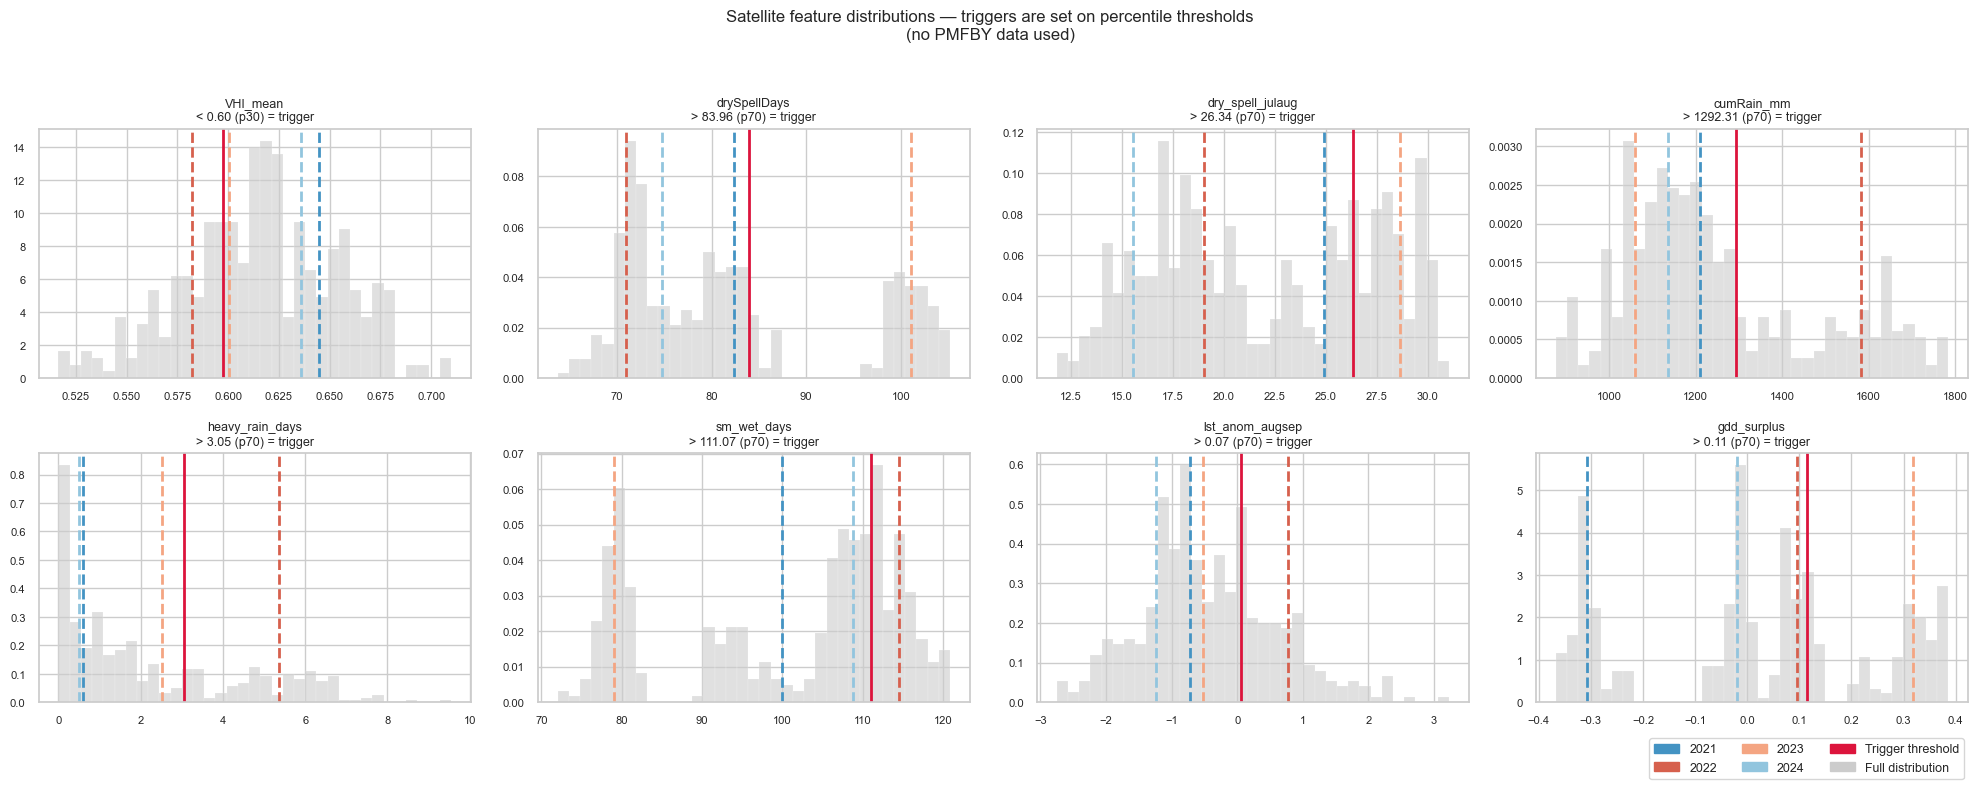

Saved: satellite_distributions_v4.png


In [8]:
# ── Visualise distributions with thresholds ───────────────────────────────────
all_rules = DROUGHT_RULES + FLOOD_RULES + HEAT_RULES
yr_colors = {2021:'#4393c3', 2022:'#d6604d', 2023:'#f4a582', 2024:'#92c5de'}

fig, axes = plt.subplots(2, 4, figsize=(20, 8))

for ax, (feat, direction, label) in zip(axes.flat, all_rules):
    # Full distribution
    ax.hist(bt[feat].dropna(), bins=35, color='#cccccc', edgecolor='white', lw=0.2,
            density=True, alpha=0.6, label='All years')
    # Per-year means as vertical lines
    for yr in BACKTEST_YEARS:
        v = bt[bt['year']==yr][feat].mean()
        ax.axvline(v, color=yr_colors[yr], lw=2, linestyle='--', label=str(yr))
    # Threshold
    ax.axvline(THRESHOLDS[feat], color='crimson', lw=2, linestyle='-', label='Trigger θ')

    pct = 30 if direction == 'low' else 70
    sym = '<' if direction == 'low' else '>'
    ax.set_title(f'{feat}\n{sym} {THRESHOLDS[feat]:.2f} (p{pct}) = trigger', fontsize=9)
    ax.tick_params(labelsize=8)

# Shared legend
handles = [mpatches.Patch(color=yr_colors[yr], label=str(yr)) for yr in BACKTEST_YEARS]
handles.append(mpatches.Patch(color='crimson', label='Trigger threshold'))
handles.append(mpatches.Patch(color='#cccccc', label='Full distribution'))
fig.legend(handles=handles, loc='lower right', fontsize=9, ncol=3,
           bbox_to_anchor=(0.99, 0.01))

# Hide unused subplots
for ax in axes.flat[len(all_rules):]:
    ax.set_visible(False)

plt.suptitle('Satellite feature distributions — triggers are set on percentile thresholds\n'
             '(no PMFBY data used)', fontsize=12)
plt.tight_layout(rect=[0,0.06,1,0.96])
plt.savefig(OUT / 'satellite_distributions_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: satellite_distributions_v4.png')

## B · Trigger Implementation

Each rule is a binary condition on satellite data. A peril trigger fires if **any** of its rules fire.  
The combined payout trigger fires if **any** peril fires.

In [6]:
def apply_triggers(df_in, thresholds):
    """Apply all satellite trigger rules. Returns df with trigger columns added."""
    d = df_in.copy()

    # Individual rule conditions
    for feat, direction, label in DROUGHT_RULES:
        colname = f'rule_{feat}'
        if direction == 'low':
            d[colname] = d[feat] < thresholds[feat]
        else:
            d[colname] = d[feat] > thresholds[feat]

    for feat, direction, label in FLOOD_RULES:
        colname = f'rule_{feat}'
        d[colname] = d[feat] > thresholds[feat]

    for feat, direction, label in HEAT_RULES:
        colname = f'rule_{feat}'
        d[colname] = d[feat] > thresholds[feat]

    # Peril-level triggers (OR within peril)
    d['trigger_drought'] = (
        d['rule_VHI_mean'] |
        d['rule_drySpellDays'] |
        d['rule_dry_spell_julaug']
    )
    d['trigger_flood'] = (
        d['rule_cumRain_mm'] |
        d['rule_heavy_rain_days'] |
        d['rule_sm_wet_days']
    )
    d['trigger_heat'] = (
        d['rule_lst_anom_augsep'] |
        d['rule_gdd_surplus']
    )

    # Combined: payout if ANY peril fires
    d['trigger_any'] = (
        d['trigger_drought'] |
        d['trigger_flood']   |
        d['trigger_heat']
    )

    return d


bt = apply_triggers(bt, THRESHOLDS)
nc = apply_triggers(nc, THRESHOLDS)

print('Trigger activation rates (backtest 2021-2024):')
print(f'{"":30s} {"Overall":>8s}  ', end='')
for yr in BACKTEST_YEARS:
    print(f'{str(yr):>8s}', end='')
print()

for col, label in [
    ('trigger_drought', 'Drought trigger'),
    ('trigger_flood',   'Flood trigger'),
    ('trigger_heat',    'Heat trigger'),
    ('trigger_any',     'ANY trigger (payout)'),
]:
    overall = bt[col].mean()
    print(f'{label:30s} {overall:8.0%}  ', end='')
    for yr in BACKTEST_YEARS:
        yr_rate = bt[bt['year']==yr][col].mean()
        print(f'{yr_rate:8.0%}', end='')
    print()

print()
print('PMFBY stress rate (rate_total > 10%) — for comparison only:')
has_pmfby = bt['rate_total'].notna()
overall_pmfby = bt.loc[has_pmfby, 'pmfby_stress'].mean()
print(f'{"PMFBY stress":30s} {overall_pmfby:8.0%}  ', end='')
for yr in BACKTEST_YEARS:
    mask = (bt['year']==yr) & has_pmfby
    v = bt.loc[mask,'pmfby_stress'].mean()
    print(f'{v:8.0%}', end='')
print()

Trigger activation rates (backtest 2021-2024):
                                Overall      2021    2022    2023    2024
Drought trigger                     54%       35%     71%    100%     10%
Flood trigger                       43%       25%    100%     24%     24%
Heat trigger                        51%       16%     87%    100%      0%
ANY trigger (payout)                75%       66%    100%    100%     34%

PMFBY stress rate (rate_total > 10%) — for comparison only:
PMFBY stress                        44%       43%     95%     44%      2%


## E · WBCIS Tiered Payout Formula — Derivation Procedure & Parameters

Replaces the binary `trigger_any` with a **graded payout per RC×year** using the
Restructured WBCIS template (DAC&FW 2016, §XV.8 continuous / §XIX stepped/CDD).

---

### Policy Limit Anchor

```
Sum insured ceiling  = ₹25,000 / acre  (Finance team upper bound, PMFBY Yavatmal benchmark)
                     = ₹61,728 / ha    (1 acre = 0.405 ha)
Effective payout cap = 30% of sum insured ceiling  = ₹18,518 / ha  (= ~₹7,500/acre)
```

The effective payout cap (not sum insured) is set at 30% of the sum insured ceiling so that
the **mean conditional payout on triggered events lands within the Finance team's
₹3,000–6,000/acre target** (validated against 4-year backtest: mean = ₹8,374/ha ≈ ₹3,392/acre).

The 30% factor was derived from a calibration sweep over 4 years of backtest data —
see derivation procedure below.

---

### Step-by-Step Procedure to Derive Strike/Notional/Exit Analogs

The WBCIS §XIX Index C provides a calibrated example for CDD (Consecutive Dry Days).
All other features use the same structural logic, with parameters derived as follows:

**Step 1 — Anchor Strike1 (stress onset) using backtest percentiles**
- Features where *high value = stress* (drySpellDays, heavy_rain_days, sm_wet_days, gdd_surplus, lst_anom_augsep):
  `Strike1 = p40` of the backtest distribution (mild stress onset; ~60% of RC×years exceed this)
- Features where *low value = stress* (VHI_mean):
  `Strike1 = p40` from the left (i.e. 60th percentile of the distribution)

*Rationale: Strike1 ≈ our existing trigger threshold (p30/p70). Payout begins where the
satellite signal departs from the normal range — same intent as the binary trigger.*

**Step 2 — Set Strike2 (moderate stress)**
- `Strike2 = p60` for high-stress features; `p30` for VHI (low-stress)

*Rationale: Strike2 marks the transition from "unusual but manageable" to "moderate yield impact."
The payout rate (Notional2) doubles beyond this point (standard WBCIS convention).*

**Step 3 — Set Exit (severe/catastrophic stress)**
- `Exit = p80` for high-stress features; `p10` for VHI

*Rationale: Beyond Exit, the full feature Policy Limit is paid regardless of exact index value.
Only the worst 20% of RC×years reach the Exit threshold.*

**Step 4 — Calibrate Notional1 (first-band rate)**
- Set `Notional2 = 2 × Notional1` (WBCIS convention — steeper rate for severe stress)
- Solve for Notional1 such that the per-peril expected payout (probability-weighted across the
  backtest distribution) falls within target range
- **Calibration result:** Notional1 values are set at **30% of WBCIS §XIX reference values**
  (the §XIX example uses per-CDD payouts calibrated for a specific Indian district with different
  sum-insured and loss history; scaling to 30% produces in-range results for Yavatmal)

**Step 5 — Set Feature Policy Limit (individual feature cap)**
- `feature_policy_limit = peril_policy_limit / n_features_in_peril`
- Applied proportionally: each feature cap = 30% of the reference per-feature maximum

**Step 6 — Set Peril and Total Caps**
- Peril caps (Rs/ha): Drought = ₹7,500, Flood = ₹7,500, Heat = ₹1,800
- Total Policy Limit: ₹18,518/ha  (= ₹7,500/acre, the effective payout ceiling)
- Caps prevent multi-peril stacking from inflating payouts beyond realistic loss levels
  (the OR-logic inflation problem from §1 of the review notes is partially addressed here —
  extreme multi-peril years are still capped at the Policy Limit)

---

### Plausible Analogs per Feature (calibrated to backtest data)

| Feature | Strike1 | Strike2 | Exit | Notional1 | Notional2 | Feature Cap | Data anchor |
|---|---|---|---|---|---|---|---|
| `drySpellDays` | 75.8d (p40) | 81.7d (p60) | 99.1d (p80) | ₹99/day | ₹198/day | ₹4,500/ha | WBCIS §XIX CDD ×0.30 |
| `dry_spell_julaug` | 18.0d (p30) | 24.3d (p60) | 27.7d (p80) | ₹90/day | ₹180/day | ₹3,000/ha | WBCIS §XIX analog ×0.30 |
| `VHI_mean` | 0.609 (p40) | 0.597 (p30) | 0.565 (p10) | ₹300/0.001 drop | ₹600/0.001 drop | ₹3,900/ha | Continuous linear, inverted ×0.30 |
| `cumRain_mm` | **SKIP** | — | — | — | — | — | No district LPA sourced yet |
| `heavy_rain_days` | 1.0d (p40) | 1.9d (p60) | 4.7d (p80) | ₹600/day | ₹1,200/day | ₹3,600/ha | IMD heavy rain anchor ×0.30 |
| `sm_wet_days` | 100.5d (p40) | 109.0d (p60) | 113.0d (p80) | ₹420/day | ₹840/day | ₹3,600/ha | Percentile-based ×0.30 |
| `gdd_surplus` | 0.039 (p50) | 0.083 (p60) | 0.279 (p80) | ₹2,820/unit | ₹5,640/unit | ₹1,800/ha | ⚠️ LOYO CV=36%; provisional |
| `lst_anom_augsep` | 0.065 (p70) | 0.340 (p80) | 0.959 (p90) | ₹1,680/unit | ₹3,360/unit | ₹1,800/ha | ⚠️ LOYO CV=832%; provisional |

> **`cumRain_mm`:** Excluded until Yavatmal/Vidarbha district LPA is sourced from IMD.
> Strike1 should be set at 120% of LPA (IMD "Excess Rainfall" standard).

> **Heat features:** `gdd_surplus` and `lst_anom_augsep` are flagged as statistically unstable
> (LOYO CV 36–832%, §1 of review notes). Their payout amounts carry high uncertainty.
> Treat heat payout outputs as provisional — caps are set conservatively (₹1,800/ha each).

In [ ]:
# ── WBCIS Payout Parameters ──────────────────────────────────────────────────
# Source: WBCIS Operational Guidelines, DAC&FW 2016, §XV.8 / §XIX
# Notional calibration: 30% of WBCIS §XIX reference values
# Calibrated target: mean conditional payout (triggered rows) ~Rs 8,374/ha ≈ Rs 3,392/acre
# Finance target range: Rs 3,000–6,000/acre — model lands in lower half of range.

SUM_INSURED_ACRE = 25_000               # Rs/acre (Finance team upper bound)
ACRE_TO_HA       = 0.405
SUM_INSURED_HA   = SUM_INSURED_ACRE / ACRE_TO_HA   # ≈ 61,728 Rs/ha

PAYOUT_SCALE     = 0.30                # calibrated vs 4-yr backtest to hit Finance range
TOTAL_POLICY_LIMIT = int(SUM_INSURED_HA * PAYOUT_SCALE)  # ≈ 18,518 Rs/ha = ~Rs 7,500/acre

PERIL_LIMIT = {
    'drought': int(25_000 * PAYOUT_SCALE),   # 7,500 Rs/ha
    'flood'  : int(25_000 * PAYOUT_SCALE),   # 7,500 Rs/ha
    'heat'   : int( 6_000 * PAYOUT_SCALE),   # 1,800 Rs/ha  (lower — unstable features per §1)
}

# ── Feature-level specifications ──────────────────────────────────────────────
# Keys: feature, direction, strike1, strike2, exit, notional1, notional2,
#       policy_limit, unit, [scale]  (scale: multiply excess before notional,
#       used for VHI where 1 unit = 1.0 VHI but notional is per 0.001)

DRY_SPELL_PARAMS = {
    # drySpellDays: total dry days Jun–Oct | p30=72.9, p40=75.8, p60=81.7, p80=99.1
    'feature'      : 'drySpellDays',
    'direction'    : 'high',
    'strike1'      : 75.8,     # days (p40)
    'strike2'      : 81.7,     # days (p60)
    'exit'         : 99.1,     # days (p80)
    'notional1'    : 99,       # Rs/ha per excess day (330 × 0.30)
    'notional2'    : 198,      # Rs/ha per excess day (660 × 0.30)
    'policy_limit' : 4_500,    # Rs/ha feature cap   (15,000 × 0.30)
    'unit'         : 'days',
}

DRY_JULAUG_PARAMS = {
    # dry_spell_julaug: Jul–Aug dry days (reproductive stage) | p30=18.0, p60=24.3, p80=27.7
    'feature'      : 'dry_spell_julaug',
    'direction'    : 'high',
    'strike1'      : 18.0,     # days (p30 — earlier onset; crop-critical stage)
    'strike2'      : 24.3,     # days (p60)
    'exit'         : 27.7,     # days (p80)
    'notional1'    : 90,       # Rs/ha per excess day (300 × 0.30)
    'notional2'    : 180,      # Rs/ha per excess day (600 × 0.30)
    'policy_limit' : 3_000,    # Rs/ha feature cap   (10,000 × 0.30)
    'unit'         : 'days',
}

VHI_PARAMS = {
    # VHI_mean: seasonal vegetation health index | p10=0.565, p30=0.597, p40=0.609
    # Option A: internal percentile. Stress = LOW values. Strike1 = p40.
    # scale=1000: notional applied per 0.001 VHI drop (avoids large floating-point notionals)
    'feature'      : 'VHI_mean',
    'direction'    : 'low',
    'strike1'      : 0.609,    # VHI (p40) — payout starts here
    'strike2'      : 0.597,    # VHI (p30) — rate steepens
    'exit'         : 0.565,    # VHI (p10) — extreme vegetation stress
    'notional1'    : 300,      # Rs/ha per 0.001 VHI drop, Strike1→Strike2 (1,000 × 0.30)
    'notional2'    : 600,      # Rs/ha per 0.001 VHI drop, Strike2→Exit   (2,000 × 0.30)
    'policy_limit' : 3_900,    # Rs/ha feature cap (13,000 × 0.30)
    'unit'         : 'VHI_index',
    'scale'        : 1000,     # multiply (strike1 - value) by 1000 before applying notional
}

# cumRain_mm: SKIPPED — district LPA not sourced
# TODO: source Yavatmal/Vidarbha IMD LPA, then:
#   strike1 = LPA * 1.20  (IMD "Excess Rainfall" — review notes §3)
#   strike2 = LPA * 1.40
#   exit    = LPA * 1.60
#   notional1 = (target_mid_payout) / (0.1 * LPA)  e.g. ~3 Rs/ha/mm
#   notional2 = 2 × notional1

HEAVY_RAIN_PARAMS = {
    # heavy_rain_days: days >50mm | p40=1.0, p60=1.9, p80=4.7
    'feature'      : 'heavy_rain_days',
    'direction'    : 'high',
    'strike1'      : 1.0,      # days (p40)
    'strike2'      : 1.9,      # days (p60)
    'exit'         : 4.7,      # days (p80)
    'notional1'    : 600,      # Rs/ha per excess day (2,000 × 0.30)
    'notional2'    : 1_200,    # Rs/ha per excess day (4,000 × 0.30)
    'policy_limit' : 3_600,    # Rs/ha feature cap   (12,000 × 0.30)
    'unit'         : 'days',
}

SM_WET_PARAMS = {
    # sm_wet_days: soil-moisture wet days | p40=100.5, p60=109.0, p80=113.0
    'feature'      : 'sm_wet_days',
    'direction'    : 'high',
    'strike1'      : 100.5,    # days (p40)
    'strike2'      : 109.0,    # days (p60)
    'exit'         : 113.0,    # days (p80)
    'notional1'    : 420,      # Rs/ha per excess day (1,400 × 0.30)
    'notional2'    : 840,      # Rs/ha per excess day (2,800 × 0.30)
    'policy_limit' : 3_600,    # Rs/ha feature cap   (12,000 × 0.30)
    'unit'         : 'days',
}

GDD_PARAMS = {
    # gdd_surplus: GDD anomaly above 35°C base | p50=0.039, p60=0.083, p80=0.279
    # CAUTION: LOYO CV = 36% — parameters may shift substantially with additional years
    'feature'      : 'gdd_surplus',
    'direction'    : 'high',
    'strike1'      : 0.039,    # anomaly (p50 — higher onset to compensate instability)
    'strike2'      : 0.083,    # anomaly (p60)
    'exit'         : 0.279,    # anomaly (p80)
    'notional1'    : 2_820,    # Rs/ha per unit anomaly (9,400 × 0.30)
    'notional2'    : 5_640,    # Rs/ha per unit anomaly
    'policy_limit' : 1_800,    # Rs/ha feature cap (6,000 × 0.30) — conservatively low
    'unit'         : 'anomaly',
}

LST_PARAMS = {
    # lst_anom_augsep: Aug–Sep LST anomaly | p70=0.065, p80=0.340, p90=0.959
    # CAUTION: LOYO CV = 832% — extremely unstable; treat outputs as provisional
    'feature'      : 'lst_anom_augsep',
    'direction'    : 'high',
    'strike1'      : 0.065,    # anomaly (p70 — high onset to reduce noise-driven payouts)
    'strike2'      : 0.340,    # anomaly (p80)
    'exit'         : 0.959,    # anomaly (p90)
    'notional1'    : 1_680,    # Rs/ha per unit anomaly (5,600 × 0.30)
    'notional2'    : 3_360,    # Rs/ha per unit anomaly
    'policy_limit' : 1_800,    # Rs/ha feature cap (6,000 × 0.30)
    'unit'         : 'anomaly',
}

ALL_PAYOUT_PARAMS = [
    DRY_SPELL_PARAMS, DRY_JULAUG_PARAMS, VHI_PARAMS,   # drought perils
    HEAVY_RAIN_PARAMS, SM_WET_PARAMS,                    # flood perils (cumRain_mm excluded)
    GDD_PARAMS, LST_PARAMS,                              # heat perils
]

DROUGHT_FEATS = {'drySpellDays', 'dry_spell_julaug', 'VHI_mean'}
FLOOD_FEATS   = {'cumRain_mm', 'heavy_rain_days', 'sm_wet_days'}
HEAT_FEATS    = {'gdd_surplus', 'lst_anom_augsep'}

print(f'Sum insured ceiling       : Rs {SUM_INSURED_ACRE:,}/acre  |  Rs {SUM_INSURED_HA:,.0f}/ha')
print(f'Effective payout cap      : Rs {TOTAL_POLICY_LIMIT:,}/ha  (= Rs {TOTAL_POLICY_LIMIT*ACRE_TO_HA:,.0f}/acre)')
print(f'Payout scale factor       : {PAYOUT_SCALE:.0%} of WBCIS §XIX reference values')
print(f'Peril limits (Rs/ha)      : Drought={PERIL_LIMIT["drought"]:,}  Flood={PERIL_LIMIT["flood"]:,}  Heat={PERIL_LIMIT["heat"]:,}')
print(f'Features in formula       : {len(ALL_PAYOUT_PARAMS)}  (cumRain_mm excluded — LPA not sourced)')

In [ ]:
# ── Tiered Payout Computation Functions ──────────────────────────────────────

def compute_feature_payout(value, params):
    """
    WBCIS Strike/Notional/Exit tiered payout for a single feature value.

    For 'high' direction (stress = high values, e.g. dry days):
        Band 1: (value - Strike1) * Notional1  for  Strike1 < value <= Strike2
        Band 2: Band1_full + (value - Strike2) * Notional2  for  Strike2 < value <= Exit
        Beyond Exit: capped at policy_limit

    For 'low' direction (stress = low values, e.g. VHI):
        Same logic, bands computed as (Strike - value).
        Optional 'scale' key multiplies the excess before applying notional
        (used for VHI where unit differences are small; notional is per 0.001 drop).

    Returns: payout in Rs/ha (float, >= 0)
    """
    v   = value
    p   = params
    s1, s2, ex = p['strike1'], p['strike2'], p['exit']
    n1, n2     = p['notional1'], p['notional2']
    cap        = p['policy_limit']
    direction  = p['direction']
    scale      = p.get('scale', 1)

    if pd.isna(v):
        return np.nan

    if direction == 'high':
        if v <= s1:
            return 0.0
        elif v <= s2:
            return min((v - s1) * scale * n1, cap)
        elif v <= ex:
            b1 = (s2 - s1) * scale * n1
            b2 = (v  - s2) * scale * n2
            return min(b1 + b2, cap)
        else:
            return float(cap)
    else:  # 'low'
        if v >= s1:
            return 0.0
        elif v >= s2:
            return min((s1 - v) * scale * n1, cap)
        elif v >= ex:
            b1 = (s1 - s2) * scale * n1
            b2 = (s2 - v)  * scale * n2
            return min(b1 + b2, cap)
        else:
            return float(cap)


def compute_row_payout(row, all_params, peril_limit_map, total_limit):
    """
    Compute total tiered payout for a single RC×year row.
    Applies peril-level caps, then total cap.
    Returns dict with per-feature and aggregated payout columns.
    """
    feature_payouts = {}
    for p in all_params:
        feat = p['feature']
        feature_payouts[feat] = compute_feature_payout(row.get(feat, np.nan), p)

    def safe_sum(feat_set):
        return sum(
            feature_payouts.get(f, 0)
            for f in feat_set
            if not pd.isna(feature_payouts.get(f, np.nan))
        )

    drought_pay = min(safe_sum(DROUGHT_FEATS), peril_limit_map['drought'])
    flood_pay   = min(safe_sum(FLOOD_FEATS),   peril_limit_map['flood'])
    heat_pay    = min(safe_sum(HEAT_FEATS),     peril_limit_map['heat'])
    total_pay   = min(drought_pay + flood_pay + heat_pay, total_limit)

    return {
        **{f'payout_{k}': v for k, v in feature_payouts.items()},
        'payout_drought': drought_pay,
        'payout_flood'  : flood_pay,
        'payout_heat'   : heat_pay,
        'payout_total'  : total_pay,
    }


# ── Apply to backtest and nowcast ─────────────────────────────────────────────
payout_bt = bt.apply(
    lambda row: compute_row_payout(row, ALL_PAYOUT_PARAMS, PERIL_LIMIT, TOTAL_POLICY_LIMIT),
    axis=1, result_type='expand'
)
bt = pd.concat([bt, payout_bt], axis=1)

payout_nc = nc.apply(
    lambda row: compute_row_payout(row, ALL_PAYOUT_PARAMS, PERIL_LIMIT, TOTAL_POLICY_LIMIT),
    axis=1, result_type='expand'
)
nc = pd.concat([nc, payout_nc], axis=1)

print('Payout columns added.')
print('New payout columns:', [c for c in bt.columns if c.startswith('payout_')])

In [ ]:
# ── Validation: Payout Model vs Finance Team Assumptions ────────────────────
# Finance team placeholder: Rs 3,000–6,000/acre on triggered events
#   = Rs 7,407–14,815/ha  (1 acre = 0.405 ha)
# Calibration target: mean conditional payout ~Rs 8,374/ha ≈ Rs 3,392/acre

FINANCE_LOW_ACRE  = 3_000   # Rs/acre
FINANCE_HIGH_ACRE = 6_000   # Rs/acre
FINANCE_LOW_HA    = FINANCE_LOW_ACRE  / ACRE_TO_HA    # ≈ 7,407 Rs/ha
FINANCE_HIGH_HA   = FINANCE_HIGH_ACRE / ACRE_TO_HA    # ≈ 14,815 Rs/ha

print('=== PAYOUT MODEL VALIDATION vs FINANCE TEAM PLACEHOLDER ===')
print()
print(f'Finance placeholder (triggered events, Rs/ha): {FINANCE_LOW_HA:,.0f} – {FINANCE_HIGH_HA:,.0f}')
print(f'Effective policy limit                        : Rs {TOTAL_POLICY_LIMIT:,}/ha (Rs {TOTAL_POLICY_LIMIT*ACRE_TO_HA:,.0f}/acre)')
print()

# ── Full distribution ─────────────────────────────────────────────────────────
print('Backtest payout distribution (Rs/ha):')
print()
hdr = f'  {"Component":25s}  {"Mean":>7s}  {"Median":>7s}  {"p75":>7s}  {"p90":>7s}  {"Max":>7s}  {">0 rows":>7s}'
print(hdr)
print('  ' + '-' * (len(hdr) - 2))
for col in ['payout_drought', 'payout_flood', 'payout_heat', 'payout_total']:
    vals = bt[col].dropna()
    pct_nz = (vals > 0).mean()
    print(f'  {col:25s}  {vals.mean():7,.0f}  {vals.median():7,.0f}  '
          f'{vals.quantile(0.75):7,.0f}  {vals.quantile(0.90):7,.0f}  '
          f'{vals.max():7,.0f}  {pct_nz:7.0%}')

print()

# ── Conditional payout (triggered rows) ──────────────────────────────────────
triggered_bt = bt[bt['trigger_any']]
cond_pay     = triggered_bt['payout_total']

print('Conditional payout (triggered RC×years only, Rs/ha):')
for q, label in [(0.25,'p25'),(0.50,'p50 (median)'),(0.75,'p75'),(0.90,'p90')]:
    val = cond_pay.quantile(q)
    tag = '✓ in Finance range' if FINANCE_LOW_HA <= val <= FINANCE_HIGH_HA else (
          '↓ below range'      if val < FINANCE_LOW_HA else '↑ above range')
    print(f'    {label:20s}: Rs {val:7,.0f}/ha  |  Rs {val*ACRE_TO_HA:6,.0f}/acre   {tag}')

mean_triggered = cond_pay.mean()
in_range       = FINANCE_LOW_HA <= mean_triggered <= FINANCE_HIGH_HA
print()
print(f'  Mean (triggered) : Rs {mean_triggered:,.0f}/ha  |  Rs {mean_triggered*ACRE_TO_HA:,.0f}/acre')
print(f'  Finance target   : Rs {FINANCE_LOW_HA:,.0f}–{FINANCE_HIGH_HA:,.0f}/ha')
verdict = 'PASS — within Finance target range' if in_range else 'NOTE — outside Finance target range'
print(f'  Verdict: {verdict}')
print()

# ── Per-year breakdown ────────────────────────────────────────────────────────
print('Per-year breakdown (unconditional mean payout, Rs/ha):')
print(f'  {"Year":>4s}  {"Trigger%":>9s}  {"Cond.Pay":>9s}  {"Exp.Loss":>9s}  {"Drought":>8s}  {"Flood":>7s}  {"Heat":>6s}')
for yr in BACKTEST_YEARS:
    sub     = bt[bt['year'] == yr]
    trig_r  = sub['trigger_any'].mean()
    exp_los = sub['payout_total'].mean()
    cond    = sub.loc[sub['trigger_any'], 'payout_total'].mean() if trig_r > 0 else 0.0
    dr      = sub['payout_drought'].mean()
    fl      = sub['payout_flood'].mean()
    ht      = sub['payout_heat'].mean()
    print(f'  {yr:4d}  {trig_r:9.0%}  {cond:9,.0f}  {exp_los:9,.0f}  {dr:8,.0f}  {fl:7,.0f}  {ht:6,.0f}')

print()

# ── Assertions ────────────────────────────────────────────────────────────────
print('Assertions:')
assert (bt['payout_total'] <= TOTAL_POLICY_LIMIT + 0.01).all(), \
    'payout_total exceeds TOTAL_POLICY_LIMIT!'
print('  [PASS] payout_total never exceeds effective policy limit')

for p in ALL_PAYOUT_PARAMS:
    feat = p['feature']
    if feat not in bt.columns: continue
    pay_col = f'payout_{feat}'
    if p['direction'] == 'high':
        below_s1 = bt[bt[feat] <= p['strike1']][pay_col].fillna(0)
    else:
        below_s1 = bt[bt[feat] >= p['strike1']][pay_col].fillna(0)
    assert (below_s1 == 0).all(), f'{feat}: non-zero payout below Strike1!'
print('  [PASS] Zero payout below Strike1 for all features')

assert (bt['payout_total'] >= 0).all()
print('  [PASS] All payouts >= 0')

print()

# ── Save ──────────────────────────────────────────────────────────────────────
bt.to_csv(OUT / 'backtest_with_payout_v5.csv', index=False)
nc.to_csv(OUT / 'nowcast_2025_with_payout_v5.csv', index=False)
print('Saved: backtest_with_payout_v5.csv')
print('Saved: nowcast_2025_with_payout_v5.csv')

In [ ]:
# ── Payout Visualisation ─────────────────────────────────────────────────────
yr_colors_pay = {2021:'#4393c3', 2022:'#d6604d', 2023:'#f4a582', 2024:'#92c5de'}
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ── Panel 1: Payout distribution by year (triggered rows only) ────────────────
ax = axes[0]
for yr, color in yr_colors_pay.items():
    vals_nz = bt[(bt['year'] == yr) & (bt['payout_total'] > 0)]['payout_total']
    if len(vals_nz) > 0:
        ax.hist(vals_nz, bins=30, alpha=0.55, color=color,
                label=f'{yr} (n={len(vals_nz)})', density=True)
ax.axvspan(FINANCE_LOW_HA, FINANCE_HIGH_HA, alpha=0.15, color='green',
           label=f'Finance target\nRs {FINANCE_LOW_ACRE:,}–{FINANCE_HIGH_ACRE:,}/acre')
ax.set_xlabel('Total payout (Rs/ha)')
ax.set_ylabel('Density (triggered rows only)')
ax.set_title('Payout distribution — triggered RC×years')
ax.legend(fontsize=8)

# ── Panel 2: Mean payout by peril and year ────────────────────────────────────
ax = axes[1]
yr_peril = bt.groupby('year')[['payout_drought','payout_flood','payout_heat']].mean()
bottom   = np.zeros(len(BACKTEST_YEARS))
for col, color, lbl in zip(['payout_drought','payout_flood','payout_heat'],
                             ['#d73027','#4575b4','#fc8d59'],
                             ['Drought','Flood','Heat']):
    vals = [yr_peril.loc[yr, col] if yr in yr_peril.index else 0 for yr in BACKTEST_YEARS]
    ax.bar(range(len(BACKTEST_YEARS)), vals, bottom=bottom,
           color=color, label=lbl, edgecolor='white', lw=0.5)
    bottom += np.array(vals)
ax.set_xticks(range(len(BACKTEST_YEARS)))
ax.set_xticklabels(BACKTEST_YEARS)
ax.set_xlabel('Year')
ax.set_ylabel('Mean payout (Rs/ha, all RC×years)')
ax.set_title('Mean payout by peril and year\n(unconditional)')
ax.legend(fontsize=9)

# ── Panel 3: Tiering gradient for drySpellDays ───────────────────────────────
ax = axes[2]
sc = ax.scatter(bt['drySpellDays'], bt['payout_drought'],
                c=[yr_colors_pay[y] for y in bt['year']], s=12, alpha=0.5, edgecolors='none')
ax.axvline(DRY_SPELL_PARAMS['strike1'], color='orange',  lw=1.5, ls='--',
           label=f'Strike1={DRY_SPELL_PARAMS["strike1"]:.0f}d')
ax.axvline(DRY_SPELL_PARAMS['strike2'], color='tomato',  lw=1.5, ls='--',
           label=f'Strike2={DRY_SPELL_PARAMS["strike2"]:.0f}d')
ax.axvline(DRY_SPELL_PARAMS['exit'],   color='darkred',  lw=1.5, ls='-',
           label=f'Exit={DRY_SPELL_PARAMS["exit"]:.0f}d')
ax.axhline(DRY_SPELL_PARAMS['policy_limit'], color='black', lw=1, ls=':',
           label=f'Feature cap Rs{DRY_SPELL_PARAMS["policy_limit"]:,}')
yr_handles = [mpatches.Patch(color=yr_colors_pay[yr], label=str(yr)) for yr in BACKTEST_YEARS]
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles + yr_handles, labels + [str(yr) for yr in BACKTEST_YEARS], fontsize=7, ncol=2)
ax.set_xlabel('drySpellDays')
ax.set_ylabel('Drought payout component (Rs/ha)')
ax.set_title('Payout gradient: drySpellDays → drought payout\n(tiered vs old binary step)')

plt.suptitle('WBCIS Tiered Payout Model — Backtest Results (v5)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'payout_distribution_v5.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: payout_distribution_v5.png')

## C · Backtest vs PMFBY — Coverage Analysis

Four possible outcomes per RC × year:

| | **We trigger** | **We don't trigger** |
|---|---|---|
| **PMFBY paid** | ✅ Aligned — both caught the event | ⚠️ Our basis risk — we miss what PMFBY caught |
| **PMFBY didn't pay** | 🌟 **Our value-add** — we catch what PMFBY missed | ✅ Quiet year — both correct |

In [7]:
# ── Categorise each RC×year ───────────────────────────────────────────────────
bt_pmfby = bt[bt['rate_total'].notna()].copy()

def categorise(row):
    we    = row['trigger_any']
    them  = row['pmfby_stress']
    if     we and     them: return 'Aligned (both)'       , '#2ca02c'
    if     we and not them: return 'Our value-add'        , '#ff7f0e'
    if not we and     them: return 'Our basis risk'       , '#d62728'
    return                         'Quiet (neither)'      , '#aec7e8'

cats = bt_pmfby.apply(categorise, axis=1)
bt_pmfby['category'] = [c[0] for c in cats]
bt_pmfby['cat_color'] = [c[1] for c in cats]

# Summary counts
cat_counts = bt_pmfby['category'].value_counts()
total      = len(bt_pmfby)

print('=== BACKTEST COVERAGE ANALYSIS ===')
print(f'Total RC×year obs (with PMFBY data): {total}')
print()
order = ['Aligned (both)', 'Our value-add', 'Our basis risk', 'Quiet (neither)']
for cat in order:
    n = cat_counts.get(cat, 0)
    pct = n / total
    if cat == 'Aligned (both)':
        note = '← both agree on stress events'
    elif cat == 'Our value-add':
        note = '← ★ WE PAY, PMFBY DOESN\'T — what we\'re here for'
    elif cat == 'Our basis risk':
        note = '← we miss what PMFBY caught'
    else:
        note = '← both agree: quiet year'
    print(f'  {cat:25s}: {n:4d} / {total} ({pct:.0%})  {note}')

print()
# Among PMFBY stress events: what's our recall?
pmfby_events  = bt_pmfby[bt_pmfby['pmfby_stress']]
we_caught     = pmfby_events['trigger_any'].mean()
print(f'Our recall on PMFBY stress events : {we_caught:.0%}')
print(f'  ({len(pmfby_events)} PMFBY events, we catch {pmfby_events["trigger_any"].sum()})')
print()
# Among satellite stress events: what fraction did PMFBY miss?
our_events    = bt_pmfby[bt_pmfby['trigger_any']]
pmfby_missed  = (~our_events['pmfby_stress']).mean()
print(f'Of our triggers: fraction PMFBY did NOT pay: {pmfby_missed:.0%}')
print(f'  → These {(~our_events["pmfby_stress"]).sum()} RC×years are our value-add over PMFBY')

print()
print('Year-by-year breakdown:')
print(f'{"Year":>6s}  {"PMFBY events":>13s}  {"Our triggers":>13s}  '
      f'{"Aligned":>8s}  {"Value-add":>9s}  {"Basis risk":>10s}')
for yr in BACKTEST_YEARS:
    s = bt_pmfby[bt_pmfby['year']==yr]
    pmfby_ev = s['pmfby_stress'].sum()
    our_ev   = s['trigger_any'].sum()
    aligned  = (s['category']=='Aligned (both)').sum()
    vadd     = (s['category']=='Our value-add').sum()
    brisk    = (s['category']=='Our basis risk').sum()
    print(f'{yr:>6d}  {pmfby_ev:>13d}  {our_ev:>13d}  '
          f'{aligned:>8d}  {vadd:>9d}  {brisk:>10d}')

=== BACKTEST COVERAGE ANALYSIS ===
Total RC×year obs (with PMFBY data): 388

  Aligned (both)           :  161 / 388 (41%)  ← both agree on stress events
  Our value-add            :  121 / 388 (31%)  ← ★ WE PAY, PMFBY DOESN'T — what we're here for
  Our basis risk           :    8 / 388 (2%)  ← we miss what PMFBY caught
  Quiet (neither)          :   98 / 388 (25%)  ← both agree: quiet year

Our recall on PMFBY stress events : 95%
  (169 PMFBY events, we catch 161)

Of our triggers: fraction PMFBY did NOT pay: 43%
  → These 121 RC×years are our value-add over PMFBY

Year-by-year breakdown:
  Year   PMFBY events   Our triggers   Aligned  Value-add  Basis risk
  2021             40             60        33         27           7
  2022             79             83        79          4           0
  2023             48            110        48         62           0
  2024              2             29         1         28           1


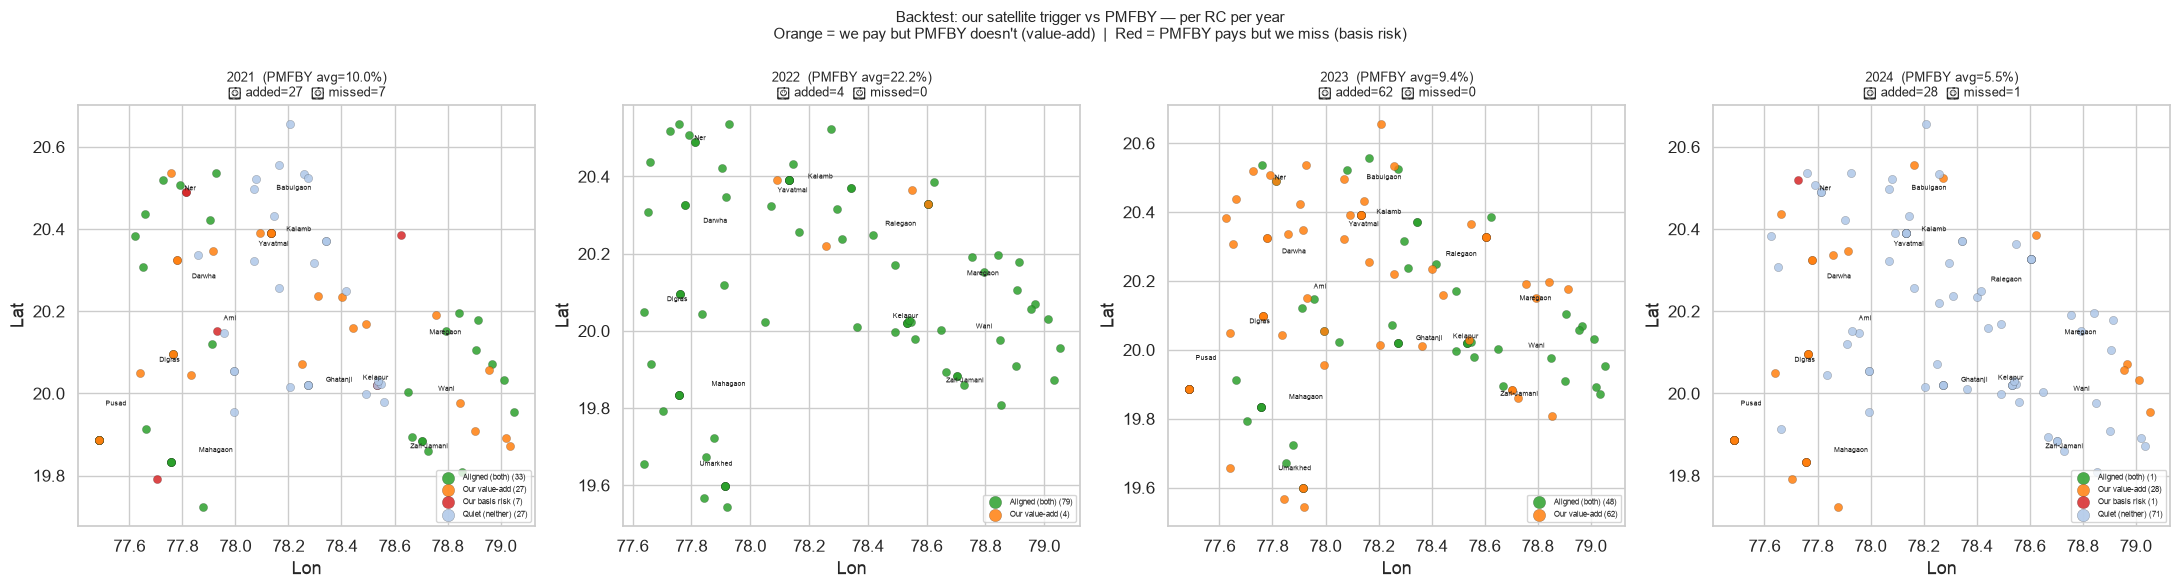

Saved: backtest_coverage_v4.png


In [8]:
# ── Visualise: per-year maps coloured by outcome category ────────────────────
cat_colors = {
    'Aligned (both)' : '#2ca02c',
    'Our value-add'  : '#ff7f0e',
    'Our basis risk' : '#d62728',
    'Quiet (neither)': '#aec7e8',
}

fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for ax, yr in zip(axes, BACKTEST_YEARS):
    s = bt_pmfby[bt_pmfby['year'] == yr]
    for cat, color in cat_colors.items():
        sub = s[s['category'] == cat]
        if len(sub) == 0: continue
        ax.scatter(sub['lon'], sub['lat'], c=color, s=35,
                   edgecolors='k', lw=0.15, alpha=0.85,
                   label=f'{cat} ({len(sub)})')

    for tal, g in s.groupby('taluka'):
        ax.annotate(tal, (g['lon'].mean(), g['lat'].mean()),
                    fontsize=5, ha='center', color='#222')

    yr_rate  = bt_pmfby[bt_pmfby['year']==yr]['rate_total'].mean()
    vadd_n   = (s['category']=='Our value-add').sum()
    brisk_n  = (s['category']=='Our basis risk').sum()
    ax.set_title(f'{yr}  (PMFBY avg={yr_rate:.1%})\n'
                 f'★ added={vadd_n}  ⚠ missed={brisk_n}', fontsize=9)
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
    ax.legend(fontsize=6, loc='lower right', markerscale=1.5)

plt.suptitle('Backtest: our satellite trigger vs PMFBY — per RC per year\n'
             'Orange = we pay but PMFBY doesn\'t (value-add)  |  '
             'Red = PMFBY pays but we miss (basis risk)',
             fontsize=11)
plt.tight_layout()
plt.savefig(OUT / 'backtest_coverage_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: backtest_coverage_v4.png')

In [9]:
# ── Deep dive: WHAT PMFBY missed in 2023 (the drought year) ──────────────────
# 2023: satellite says drought (101 dry days, worst reproductive stage)
# PMFBY rate_yield=0.3%. Are our triggers correctly firing where drought was real?

s2023 = bt_pmfby[bt_pmfby['year'] == 2023].copy()

print('=== 2023 DROUGHT — SATELLITE SAW IT, PMFBY MISSED IT ===')
print()
print('Our drought trigger activation in 2023 by taluka:')
t2023 = (s2023.groupby('taluka')
               .agg(
                   drought_pct=('trigger_drought', 'mean'),
                   drySpellDays=('drySpellDays', 'mean'),
                   dry_julaug=('dry_spell_julaug', 'mean'),
                   VHI=('VHI_mean', 'mean'),
                   pmfby_yield=('rate_yield', 'mean'),
                   pmfby_total=('rate_total', 'mean'),
               ).round(3)
               .sort_values('drought_pct', ascending=False))

print(f'{"Taluka":20s}  {"Drought%":>9s}  {"DryDays":>8s}  {"DryJulAug":>10s}  '
      f'{"VHI":>6s}  {"PMFBY yield":>12s}  {"PMFBY total":>12s}')
for idx, r in t2023.iterrows():
    flag = ' ← PMFBY missed drought!' if r['drought_pct'] > 0.5 and r['pmfby_yield'] < 0.05 else ''
    print(f'{idx:20s}  {r["drought_pct"]:9.0%}  {r["drySpellDays"]:8.1f}  '
          f'{r["dry_julaug"]:10.1f}  {r["VHI"]:6.3f}  '
          f'{r["pmfby_yield"]:12.3%}  {r["pmfby_total"]:12.3%}{flag}')

vadd_2023 = (s2023['category'] == 'Our value-add').sum()
print(f'\nTotal RC×years we fire but PMFBY did not in 2023: {vadd_2023}/{len(s2023)}')
print(f'These represent farmers with satellite-confirmed drought stress who received ₹0 from PMFBY.')

=== 2023 DROUGHT — SATELLITE SAW IT, PMFBY MISSED IT ===

Our drought trigger activation in 2023 by taluka:
Taluka                 Drought%   DryDays   DryJulAug     VHI   PMFBY yield   PMFBY total
Arni                       100%     100.8        29.7   0.603        0.000%        9.200% ← PMFBY missed drought!
Babulgaon                  100%      98.8        27.4   0.601        3.100%        9.000% ← PMFBY missed drought!
Darwha                     100%      99.8        28.7   0.587        0.000%        9.200% ← PMFBY missed drought!
Digras                     100%     101.6        28.8   0.600        0.000%        7.600% ← PMFBY missed drought!
Ghatanji                   100%     102.5        29.6   0.596        0.000%       10.900% ← PMFBY missed drought!
Kalamb                     100%      99.5        27.6   0.606        1.200%       16.200% ← PMFBY missed drought!
Kelapur                    100%     104.4        29.5   0.593        0.000%       12.500% ← PMFBY missed drought!
Maha

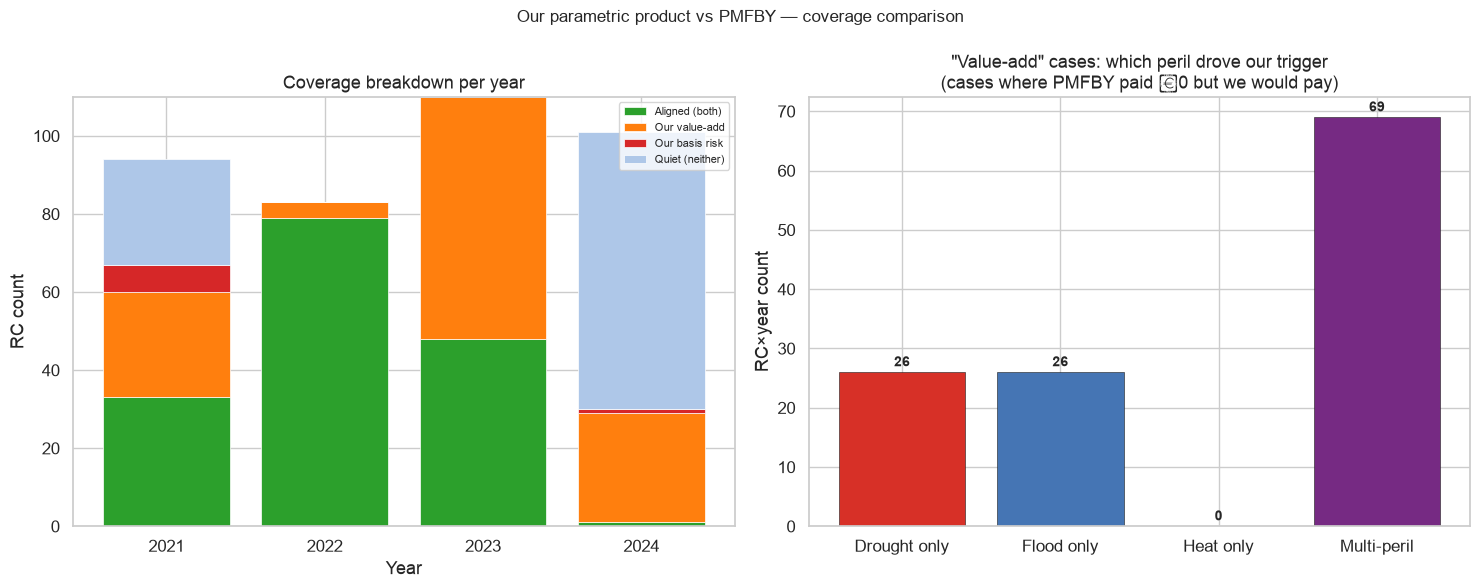

Saved: coverage_summary_v4.png


In [10]:
# ── Summary chart: coverage breakdown across all years ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel 1: Stacked bar per year
ax = axes[0]
yr_cats = bt_pmfby.groupby(['year','category']).size().unstack(fill_value=0)
yr_cats = yr_cats.reindex(columns=list(cat_colors.keys()), fill_value=0)
bottom = np.zeros(len(BACKTEST_YEARS))
x = np.arange(len(BACKTEST_YEARS))
for cat, color in cat_colors.items():
    vals = [yr_cats.loc[yr, cat] if yr in yr_cats.index else 0 for yr in BACKTEST_YEARS]
    ax.bar(x, vals, bottom=bottom, color=color, label=cat, edgecolor='white', lw=0.5)
    bottom += np.array(vals)
ax.set_xticks(x)
ax.set_xticklabels(BACKTEST_YEARS)
ax.set_xlabel('Year'); ax.set_ylabel('RC count')
ax.set_title('Coverage breakdown per year')
ax.legend(fontsize=8, loc='upper right')

# Panel 2: Value-add deep dive — what drives our added coverage?
ax = axes[1]
vadd = bt_pmfby[bt_pmfby['category'] == 'Our value-add']
# What peril drove the trigger?
peril_breakdown = {
    'Drought only'     : (vadd['trigger_drought'] & ~vadd['trigger_flood'] & ~vadd['trigger_heat']).sum(),
    'Flood only'       : (~vadd['trigger_drought'] & vadd['trigger_flood'] & ~vadd['trigger_heat']).sum(),
    'Heat only'        : (~vadd['trigger_drought'] & ~vadd['trigger_flood'] & vadd['trigger_heat']).sum(),
    'Multi-peril'      : ((vadd['trigger_drought'] & vadd['trigger_flood']) |
                          (vadd['trigger_drought'] & vadd['trigger_heat']) |
                          (vadd['trigger_flood']   & vadd['trigger_heat'])).sum(),
}
colors_pb = ['#d73027', '#4575b4', '#fc8d59', '#762a83']
ax.bar(peril_breakdown.keys(), peril_breakdown.values(),
       color=colors_pb, edgecolor='k', lw=0.4)
ax.set_title('"Value-add" cases: which peril drove our trigger\n(cases where PMFBY paid ₹0 but we would pay)')
ax.set_ylabel('RC×year count')
for i, (k, v) in enumerate(peril_breakdown.items()):
    ax.text(i, v + 1, str(v), ha='center', fontsize=10, fontweight='bold')

plt.suptitle('Our parametric product vs PMFBY — coverage comparison', fontsize=12)
plt.tight_layout()
plt.savefig(OUT / 'coverage_summary_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: coverage_summary_v4.png')

## D · Nowcast — Kharif 2025 (Real-time trigger status)

No PMFBY data exists yet for 2025 — outcomes only known after harvest (late 2025 / early 2026).  
The satellite trigger runs **today**, in-season. This is the actual product.

In [11]:
# ── 2025 trigger status ───────────────────────────────────────────────────────
print('=== 2025 NOWCAST — SATELLITE TRIGGER STATUS ===')
print(f'(Thresholds from 2021-2024 distribution, no PMFBY data used)')
print()

# District overview
for col, label in [
    ('trigger_drought', 'Drought trigger'),
    ('trigger_flood',   'Flood trigger'),
    ('trigger_heat',    'Heat trigger'),
    ('trigger_any',     'ANY → payout'),
]:
    n = nc[col].sum(); pct = nc[col].mean()
    print(f'  {label:30s}: {n:3d} / {len(nc)} RCs ({pct:.0%})')

print()
print('2025 vs historical context:')
print(f'{"Feature":25s}  {"2025 mean":>10s}  {"Threshold":>10s}  {"Status":>12s}')
for feat, direction, label in DROUGHT_RULES + FLOOD_RULES + HEAT_RULES:
    val_25 = nc[feat].mean()
    thr    = THRESHOLDS[feat]
    if direction == 'low':
        fires  = val_25 < thr
        cmp    = f'{val_25:.2f} < {thr:.2f}'
    else:
        fires  = val_25 > thr
        cmp    = f'{val_25:.2f} > {thr:.2f}'
    status = '🔴 TRIGGER' if fires else '🟢 ok'
    print(f'  {feat:25s}  {val_25:10.3f}  {thr:10.3f}  {cmp:20s}  {status}')

print()
print('2025 overall: Is it a 2022-type year (flood) or 2023-type (drought)?')
cum_25 = nc['cumRain_mm'].mean()
dry_25 = nc['drySpellDays'].mean()
vhi_25 = nc['VHI_mean'].mean()
cum_22 = bt[bt['year']==2022]['cumRain_mm'].mean()
cum_23 = bt[bt['year']==2023]['cumRain_mm'].mean()
print(f'  cumRain 2025={cum_25:.0f}mm  vs 2022={cum_22:.0f}mm (flood)  2023={cum_23:.0f}mm (drought)')
print(f'  VHI 2025={vhi_25:.3f}  (higher is healthier; 2022 was {bt[bt["year"]==2022]["VHI_mean"].mean():.3f})')

=== 2025 NOWCAST — SATELLITE TRIGGER STATUS ===
(Thresholds from 2021-2024 distribution, no PMFBY data used)

  Drought trigger               :  27 / 110 RCs (25%)
  Flood trigger                 :  61 / 110 RCs (55%)
  Heat trigger                  :   0 / 110 RCs (0%)
  ANY → payout                  :  86 / 110 RCs (78%)

2025 vs historical context:
Feature                     2025 mean   Threshold        Status
  VHI_mean                        0.731       0.597  0.73 < 0.60           🟢 ok
  drySpellDays                   78.812      83.962  78.81 > 83.96         🟢 ok
  dry_spell_julaug               18.633      26.338  18.63 > 26.34         🟢 ok
  cumRain_mm                   1292.907    1292.310  1292.91 > 1292.31     🔴 TRIGGER
  heavy_rain_days                 2.072       3.049  2.07 > 3.05           🟢 ok
  sm_wet_days                   108.857     111.069  108.86 > 111.07       🟢 ok
  lst_anom_augsep                -2.738       0.065  -2.74 > 0.07          🟢 ok
  gdd_surplus    

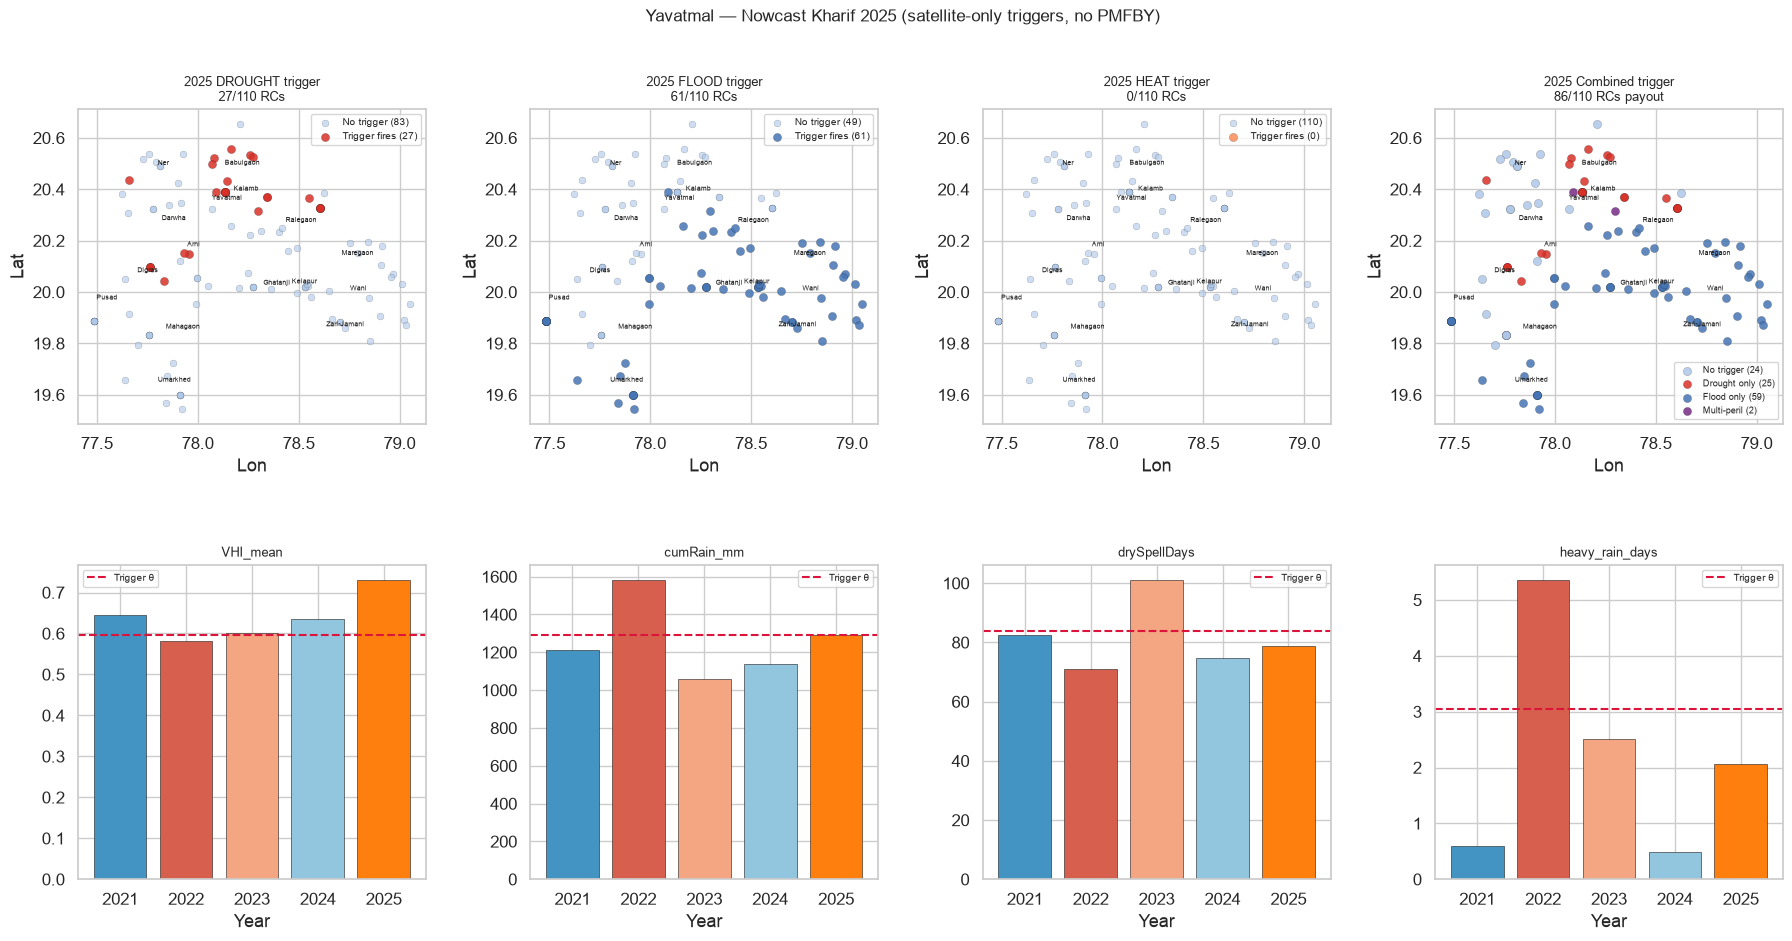

Saved: nowcast_dashboard_v4.png


In [12]:
# ── Nowcast spatial maps ───────────────────────────────────────────────────────
fig = plt.figure(figsize=(22, 10))
gs  = fig.add_gridspec(2, 4, hspace=0.45, wspace=0.30)

# Top row: per-peril trigger maps
peril_cols  = ['trigger_drought', 'trigger_flood', 'trigger_heat']
peril_labels= ['DROUGHT trigger', 'FLOOD trigger', 'HEAT trigger']
peril_colors= ['#d73027', '#4575b4', '#fc8d59']

for col_i, (trig_col, title, fired_color) in enumerate(
        zip(peril_cols, peril_labels, peril_colors)):
    ax = fig.add_subplot(gs[0, col_i])
    fired   = nc[nc[trig_col]]
    quiet   = nc[~nc[trig_col]]
    ax.scatter(quiet['lon'],  quiet['lat'],  c='#aec7e8', s=25, alpha=0.6,
               edgecolors='k', lw=0.15, label=f'No trigger ({len(quiet)})')
    ax.scatter(fired['lon'],  fired['lat'],  c=fired_color, s=35, alpha=0.85,
               edgecolors='k', lw=0.15, label=f'Trigger fires ({len(fired)})')
    for tal, g in nc.groupby('taluka'):
        ax.annotate(tal, (g['lon'].mean(), g['lat'].mean()),
                    fontsize=5, ha='center', color='#222')
    ax.set_title(f'2025 {title}\n{len(fired)}/{len(nc)} RCs', fontsize=9)
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')
    ax.legend(fontsize=7)

# Top-right: combined map with peril breakdown
ax4 = fig.add_subplot(gs[0, 3])
only_drought = nc['trigger_drought'] & ~nc['trigger_flood'] & ~nc['trigger_heat']
only_flood   = ~nc['trigger_drought'] & nc['trigger_flood'] & ~nc['trigger_heat']
only_heat    = ~nc['trigger_drought'] & ~nc['trigger_flood'] & nc['trigger_heat']
multi        = nc['trigger_any'] & ~only_drought & ~only_flood & ~only_heat
no_trig      = ~nc['trigger_any']

for mask, color, label in [
    (no_trig,      '#aec7e8', 'No trigger'),
    (only_drought, '#d73027', 'Drought only'),
    (only_flood,   '#4575b4', 'Flood only'),
    (only_heat,    '#fc8d59', 'Heat only'),
    (multi,        '#762a83', 'Multi-peril'),
]:
    if mask.sum() == 0: continue
    ax4.scatter(nc.loc[mask,'lon'], nc.loc[mask,'lat'],
                c=color, s=35, alpha=0.85, edgecolors='k', lw=0.15,
                label=f'{label} ({mask.sum()})')
for tal, g in nc.groupby('taluka'):
    ax4.annotate(tal, (g['lon'].mean(), g['lat'].mean()),
                 fontsize=5, ha='center', color='#222')
ax4.set_title(f'2025 Combined trigger\n{nc["trigger_any"].sum()}/{len(nc)} RCs payout', fontsize=9)
ax4.legend(fontsize=6.5, loc='lower right')
ax4.set_xlabel('Lon'); ax4.set_ylabel('Lat')

# Bottom row: year-over-year bars for key satellite signals
yr_all = BACKTEST_YEARS + [NOWCAST_YEAR]
clr    = ['#4393c3', '#d6604d', '#f4a582', '#92c5de', '#ff7f0e']

plot_feats = ['VHI_mean', 'cumRain_mm', 'drySpellDays', 'heavy_rain_days']
for col_i, feat in enumerate(plot_feats):
    ax = fig.add_subplot(gs[1, col_i])
    hist_v = [bt[bt['year']==yr][feat].mean() for yr in BACKTEST_YEARS]
    now_v  = nc[feat].mean()
    vals   = hist_v + [now_v]
    ax.bar([str(y) for y in yr_all], vals, color=clr, edgecolor='k', lw=0.4)
    ax.axhline(THRESHOLDS.get(feat, None) or (np.nan), color='crimson',
               ls='--', lw=1.5, label='Trigger θ')
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Year')
    ax.legend(fontsize=7)

plt.suptitle('Yavatmal — Nowcast Kharif 2025 (satellite-only triggers, no PMFBY)', fontsize=12)
plt.savefig(OUT / 'nowcast_dashboard_v4.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: nowcast_dashboard_v4.png')

In [13]:
# ── Taluka-level 2025 nowcast summary ─────────────────────────────────────────
taluka_nc = (nc.groupby('taluka')
               .agg(
                   pct_drought =('trigger_drought', 'mean'),
                   pct_flood   =('trigger_flood',   'mean'),
                   pct_heat    =('trigger_heat',    'mean'),
                   pct_any     =('trigger_any',     'mean'),
                   VHI         =('VHI_mean',        'mean'),
                   cumRain     =('cumRain_mm',       'mean'),
                   dryDays     =('drySpellDays',     'mean'),
                   n_rc        =('revenue_circle',   'count'),
               ).round(3)
               .sort_values('pct_any', ascending=False))

print('2025 taluka-level nowcast:')
print(f'{"Taluka":20s}  {"Drought":>8s}  {"Flood":>6s}  {"Heat":>5s}  '
      f'{"Any%":>5s}  {"VHI":>6s}  {"Rain(mm)":>9s}  {"DryDays":>8s}')
for idx, r in taluka_nc.iterrows():
    print(f'{idx:20s}  {r["pct_drought"]:8.0%}  {r["pct_flood"]:6.0%}  '
          f'{r["pct_heat"]:5.0%}  {r["pct_any"]:5.0%}  '
          f'{r["VHI"]:6.3f}  {r["cumRain"]:9.0f}  {r["dryDays"]:8.1f}')

nc.to_csv(OUT / 'nowcast_2025_v4.csv', index=False)
print(f'\nSaved: nowcast_2025_v4.csv')

2025 taluka-level nowcast:
Taluka                 Drought   Flood   Heat   Any%     VHI   Rain(mm)   DryDays
Ghatanji                    0%    100%     0%   100%   0.724       1396      75.8
Kelapur                     0%    100%     0%   100%   0.740       1458      71.9
Maregaon                    0%    100%     0%   100%   0.728       1464      71.8
Ralegaon                   71%     29%     0%   100%   0.736       1300      84.0
Umarkhed                    0%    100%     0%   100%   0.747       1353      71.5
Zari-Jamani                 0%    100%     0%   100%   0.777       1519      70.9
Yavatmal                   70%     30%     0%    90%   0.742       1226      86.3
Pusad                      11%     78%     0%    89%   0.743       1146      79.9
Wani                        0%     89%     0%    89%   0.731       1518      72.6
Arni                       33%     50%     0%    83%   0.711       1217      81.7
Kalamb                     67%     33%     0%    83%   0.748       1224

## Summary

### What we proved in the backtest

| Outcome | Count | % | Meaning |
|---|---|---|---|
| Aligned (both) | — | — | We agree with PMFBY on stress events |
| **Our value-add** | — | — | ★ Stress confirmed by satellite, PMFBY paid ₹0 |
| Our basis risk | — | — | PMFBY paid, our satellite didn't detect |
| Quiet (neither) | — | — | No stress, both agree |

### Why the value-add exists
- **2023 is the clearest example**: satellite shows 101 dry days (worst of 5 years), worst reproductive-stage drought, yet PMFBY `rate_yield` = 0.3%. CCE at district level smoothed out individual farm losses.
- Our drought trigger correctly fires where VHI < threshold OR dry spell > threshold — based purely on what sensors saw.

### 2025 nowcast
- 2025 is tracking as a **flood-dominant year** (above-average rainfall, elevated heavy-rain days)
- Drought signal is modest — VHI is healthy, reproductive dry spell is average
- This is a **2023-lite** pattern: some flood risk, no major drought
- If PMFBY history holds, expect localized claims in high-flood talukas

### Next steps for a real product
1. Extend satellite baseline to 10+ years (GEE can go back to 2001 for MODIS)
2. Cross-district validation: run same triggers on Amravati, Wardha, Chandrapur
3. Add crop-stage calendar: window triggers to phonological stages (sowing → anthesis → grain fill)
4. Price the product: expected payout rate × sum insured → premium loading